In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [2]:
conn = sqlite3.connect('../data/database/data_mart.db')

In [3]:
pd.read_sql("SELECT * FROM data_mart LIMIT 5", conn)

,order_id,order_item_id,product_id,customer_id,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,price,freight_value,revenue,product_category_name,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,2017-09-20 23:43:48,58.90,13.29,72.19,cool_stuff,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,2017-05-12 16:04:24,239.90,19.93,259.83,pet_shop,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,2018-01-22 13:19:16,199.00,17.87,216.87,moveis_decoracao,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,2018-08-14 13:32:39,12.99,12.79,25.78,perfumaria,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,2017-03-01 16:42:31,199.90,18.14,218.04,ferramentas_jardim,varzea paulista,SP


In [4]:
pd.read_sql("SELECT * FROM orders_agg LIMIT 5", conn)

,order_id,revenue,order_purchase_timestamp,customer_unique_id,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,RJ
1,00018f77f2f0320c557190d7a144bdd3,259.83,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,SP
2,000229ec398224ef6ca0657da4fc703e,216.87,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,MG
3,00024acbcdf0a6daa1e931b038114c75,25.78,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,SP


## Analysis of the number and revenue of orders by month

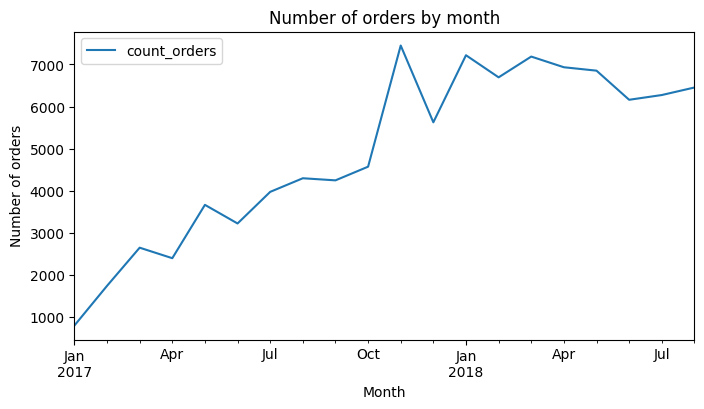

In [5]:
orders_per_months = pd.read_sql(
    """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(*) AS count_orders
    FROM orders_agg
    GROUP BY month
    """, conn)
orders_per_months['month'] = pd.to_datetime(orders_per_months['month'])
orders_per_months.set_index('month', inplace=True)
orders_per_months.plot(figsize=(8,4))
plt.title('Number of orders by month')
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.savefig('../reports/figures/01_Number_of_orders_by_month.png')

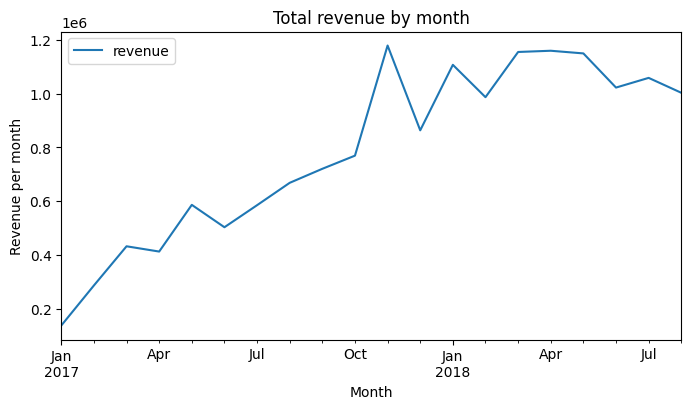

In [6]:
revenue_per_months = pd.read_sql(
    """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        SUM(revenue) AS revenue
    FROM orders_agg
    GROUP BY month
    """, conn)
revenue_per_months['month'] = pd.to_datetime(revenue_per_months['month'])
revenue_per_months.set_index('month', inplace=True)
revenue_per_months.plot(figsize=(8,4))
plt.title('Total revenue by month')
plt.xlabel('Month')
plt.ylabel('Revenue per month')
plt.savefig('../reports/figures/02_Revenue_by_month.png')

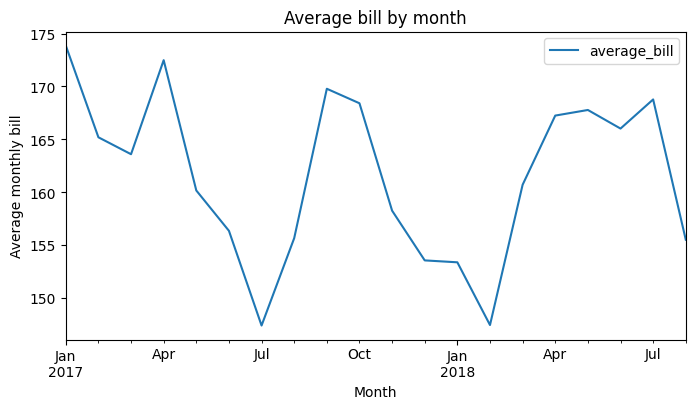

In [7]:
averagebill_per_months = pd.read_sql(
    """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        SUM(revenue)/COUNT(*) AS average_bill
    FROM orders_agg
    GROUP BY month
    """, conn)
averagebill_per_months['month'] = pd.to_datetime(averagebill_per_months['month'])
averagebill_per_months.set_index('month', inplace=True)
averagebill_per_months.plot(figsize=(8,4))
plt.title('Average bill by month')
plt.xlabel('Month')
plt.ylabel('Average monthly bill')
plt.savefig('../reports/figures/03_Average_bill_by_month.png')

#### Insights:
- Revenue growth is driven by increasing order volume (7000 peak in Nov 2017)
- AOV remains stable (150 – 175), indicating no efficiency improvement

## Category analysis

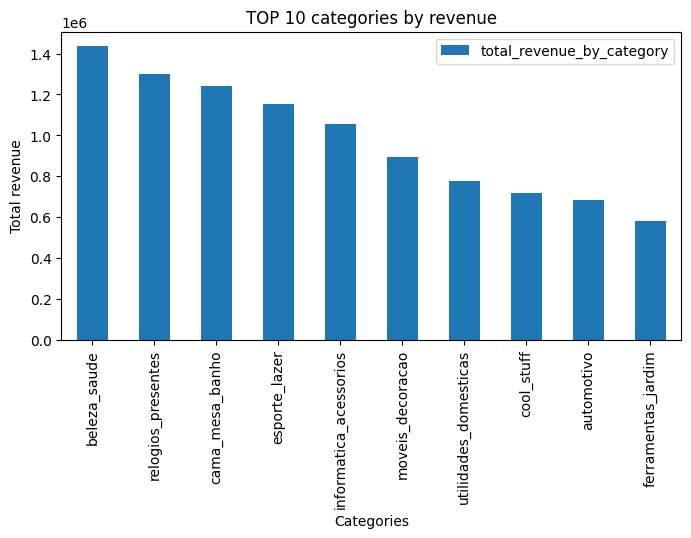

In [8]:
top_categories_by_revenue = pd.read_sql(
    """
    SELECT 
        SUM(revenue) AS total_revenue_by_category,
        product_category_name
    FROM data_mart
    GROUP BY product_category_name
    ORDER BY total_revenue_by_category DESC
    LIMIT 10
    """, conn)
top_categories_by_revenue.set_index('product_category_name', inplace=True)
top_categories_by_revenue.plot(kind='bar', figsize=(8,4))
plt.title('TOP 10 categories by revenue')
plt.xlabel('Categories')
plt.ylabel('Total revenue')
plt.savefig('../reports/figures/04_TOP_10_categories_by_revenue.png')

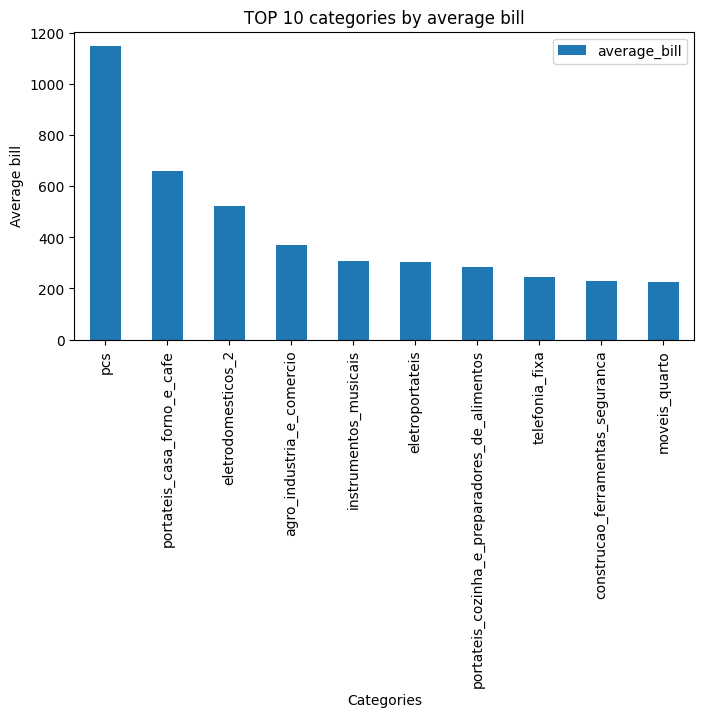

In [9]:
top_categories_by_average_bill = pd.read_sql(
    """
    SELECT 
        SUM(revenue)/COUNT(order_id) AS average_bill,
        product_category_name
    FROM data_mart
    GROUP BY product_category_name
    ORDER BY average_bill DESC
    LIMIT 10
    """, conn)
top_categories_by_average_bill.set_index('product_category_name', inplace=True)
top_categories_by_average_bill.plot(kind='bar', figsize=(8,4))
plt.title('TOP 10 categories by average bill')
plt.xlabel('Categories')
plt.ylabel('Average bill')
plt.savefig('../reports/figures/05_TOP_10_categories_by_average_bill.png')

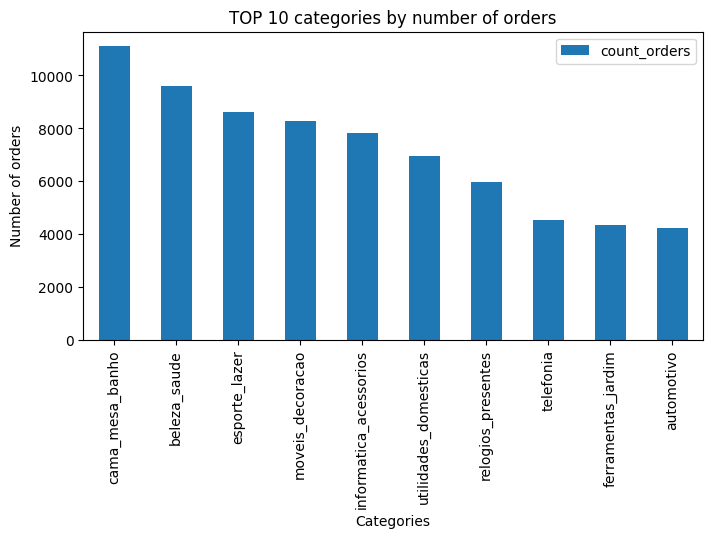

In [10]:
top_categories_by_count_orders = pd.read_sql(
    """
    SELECT
        COUNT(order_id) AS count_orders,
        product_category_name
    FROM data_mart
    GROUP BY product_category_name
    ORDER BY count_orders DESC
    LIMIT 10
    """, conn)
top_categories_by_count_orders.set_index('product_category_name', inplace=True)
top_categories_by_count_orders.plot(kind='bar', figsize=(8,4))
plt.title('TOP 10 categories by number of orders')
plt.xlabel('Categories')
plt.ylabel('Number of orders')
plt.savefig('../reports/figures/06_TOP_10_categories_by_number_of_orders.png')

In [11]:
categoty_telefonia = pd.read_sql(
    """
    SELECT
        SUM(revenue) AS total_revenue,
        product_category_name
    FROM data_mart
    GROUP BY product_category_name
    ORDER BY total_revenue DESC
    LIMIT 14
    """, conn)
categoty_telefonia

,total_revenue,product_category_name
0,1435611.23,beleza_saude
1,1302073.57,relogios_presentes
2,1241075.14,cama_mesa_banho
3,1152729.37,esporte_lazer
4,1057532.31,informatica_acessorios
5,895323.28,moveis_decoracao
6,776855.23,utilidades_domesticas
7,718002.84,cool_stuff
8,683126.76,automotivo
9,582754.02,ferramentas_jardim


#### Insights:
- Revenue is concentrated in a small set of core categories (top-5 drive the majority of revenue)
- Revenue and order volume are strongly aligned across categories
- (top categories overlap 90%), with minor exceptions (e.g. 'telephone')
- High AOV categories differ from high-volume and high-revenue categories, indicating a separate premium segment

## Analysis by region

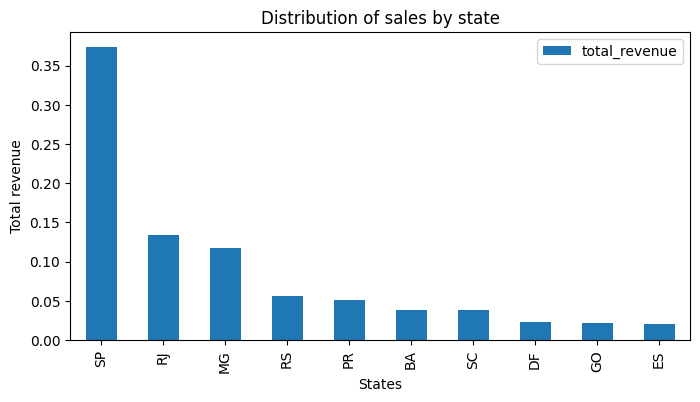

In [12]:
revenue_by_states = pd.read_sql(
    """
    SELECT
        SUM(revenue) / (SELECT SUM(revenue) from data_mart) AS total_revenue,
        customer_state
    FROM orders_agg
    GROUP BY customer_state
    ORDER BY total_revenue DESC
    LIMIT 10
    """, conn)
revenue_by_states.set_index('customer_state', inplace=True)
revenue_by_states.plot(kind='bar', figsize=(8,4))
plt.title('Distribution of sales by state')
plt.xlabel('States')
plt.ylabel('Total revenue')
plt.savefig('../reports/figures/07_Distribution_of_sales_by_state.png')

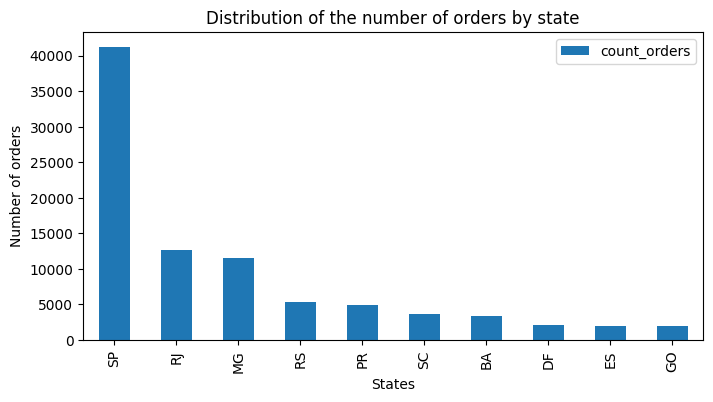

In [13]:
count_orders_by_states = pd.read_sql(
    """
    SELECT
        COUNT(order_id) AS count_orders,
        customer_state
    FROM orders_agg
    GROUP BY customer_state
    ORDER BY count_orders DESC
    LIMIT 10
    """, conn)
count_orders_by_states.set_index('customer_state', inplace=True)
count_orders_by_states.plot(kind='bar', figsize=(8,4))
plt.title('Distribution of the number of orders by state')
plt.xlabel('States')
plt.ylabel('Number of orders')
plt.savefig('../reports/figures/08_Distribution_of_the_number_of_orders_by_state.png')

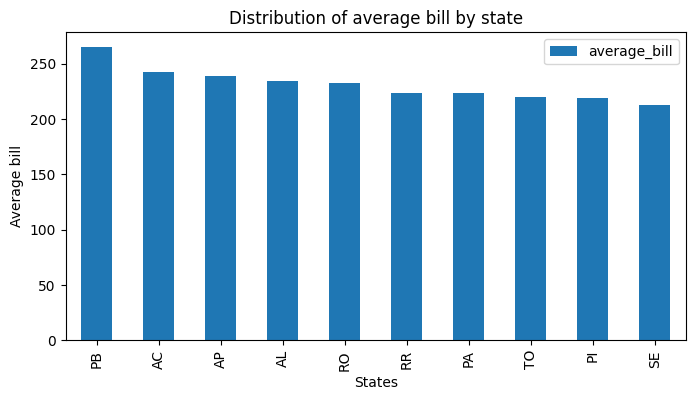

In [14]:
average_bill_by_states = pd.read_sql(
    """
    SELECT
        SUM(revenue)/COUNT(order_id) AS average_bill,
        customer_state
    FROM orders_agg
    GROUP BY customer_state
    ORDER BY average_bill DESC
    LIMIT 10
    """, conn)
average_bill_by_states.set_index('customer_state', inplace=True)
average_bill_by_states.plot(kind='bar', figsize=(8,4))
plt.title('Distribution of average bill by state')
plt.xlabel('States')
plt.ylabel('Average bill')
plt.savefig('../reports/figures/09_Distribution_of_average_bill_by_state.png')

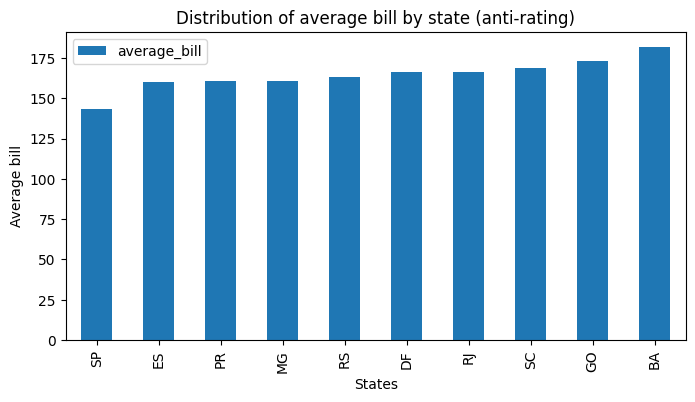

In [15]:
anti_average_bill_by_states = pd.read_sql(
    """
    SELECT
        SUM(revenue)/COUNT(order_id) AS average_bill,
        customer_state
    FROM orders_agg
    GROUP BY customer_state
    ORDER BY average_bill
    LIMIT 10
    """, conn)
anti_average_bill_by_states.set_index('customer_state', inplace=True)
anti_average_bill_by_states.plot(kind='bar', figsize=(8,4))
plt.title('Distribution of average bill by state (anti-rating)')
plt.xlabel('States')
plt.ylabel('Average bill')
plt.savefig('../reports/figures/10_Distribution_of_average_bill_by_state_anti_rating.png')

In [16]:
sum_revenue = pd.read_sql(
    """SELECT SUM(revenue) FROM orders_agg""", conn)
6000000/sum_revenue

,SUM(revenue)
0,0.380079


In [17]:
count_orders = pd.read_sql(
    """SELECT COUNT(order_id) FROM orders_agg""", conn)
40000/count_orders

,COUNT(order_id)
0,0.406698


#### Insights:
- Sales are highly concentrated in SP (40% of revenue and orders), driven by volume rather than higher AOV
- High-AOV states (PB, AC, AP, AL, RO) have low sales volume, while high-volume states (SP, RJ, MG, RS, PR) show lower AOV

## Customer behavior analysis

In [18]:
arppu = pd.read_sql("SELECT SUM(revenue)/COUNT(DISTINCT customer_unique_id) AS arppu FROM data_mart",conn)
arppu.set_index('arppu', inplace=True)
arppu

""
arppu
165.959184


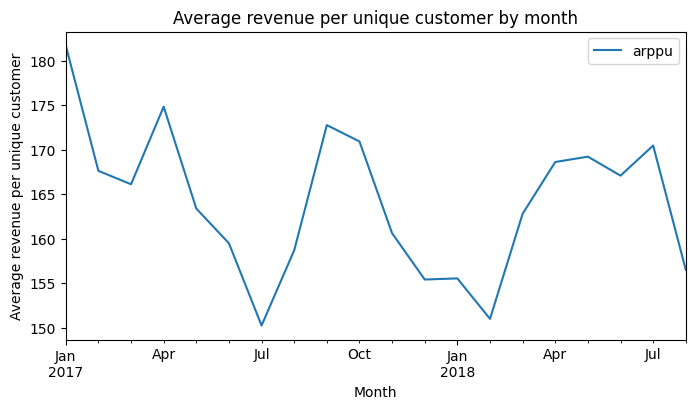

In [19]:
arppu = pd.read_sql(
    """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        SUM(revenue)/COUNT(DISTINCT customer_unique_id) AS arppu
    FROM data_mart
    GROUP BY month
    """, conn)
arppu['month'] = pd.to_datetime(arppu['month'])
arppu.set_index('month', inplace=True)
arppu.plot(figsize=(8,4))
plt.title('Average revenue per unique customer by month')
plt.xlabel('Month')
plt.ylabel('Average revenue per unique customer')
plt.savefig('../reports/figures/11_Average_revenue_per_unique_customer_by_month.png')

#### ARPPU = 166 (stable 150 – 180), slight downward trend observed

In [20]:
count_orders_per_unique_customer = pd.read_sql(
    """
    SELECT 
        COUNT(DISTINCT order_id) / CAST(COUNT(DISTINCT customer_unique_id) AS float) AS count_orders_per_unique_customer 
    FROM data_mart
    """, conn)
count_orders_per_unique_customer.set_index('count_orders_per_unique_customer', inplace=True)
count_orders_per_unique_customer

""
count_orders_per_unique_customer
1.033978


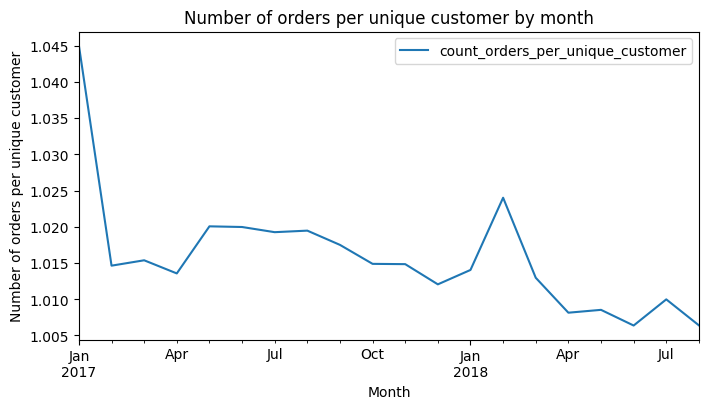

In [21]:
count_orders_per_unique_customer = pd.read_sql(
    """
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(DISTINCT order_id) / CAST(COUNT(DISTINCT customer_unique_id) AS float) AS count_orders_per_unique_customer
    FROM data_mart
    GROUP BY month
    """,conn)
count_orders_per_unique_customer['month'] = pd.to_datetime(count_orders_per_unique_customer['month'])
count_orders_per_unique_customer.set_index('month', inplace=True)
count_orders_per_unique_customer.plot(figsize=(8,4))
plt.title('Number of orders per unique customer by month')
plt.xlabel('Month')
plt.ylabel('Number of orders per unique customer')
plt.savefig('../reports/figures/12_Number_of_orders_per_unique_customer_by_month.png')

#### Insights:
- Average orders per customer = 1,03, extremely low repeat purchase rate  
- Customer base is dominated by one-time buyers  
- Slight downward trend driven by influx of new single-purchase customers

In [22]:
share_of_repeat_customers = pd.read_sql(
    """
    SELECT
        1 - CAST(COUNT(DISTINCT customer_unique_id) AS float) / COUNT(DISTINCT customer_id) AS share_of_repeat_customers
    FROM data_mart
    """, conn)
share_of_repeat_customers.set_index('share_of_repeat_customers', inplace=True)
share_of_repeat_customers

""
share_of_repeat_customers
0.032861


## Average bill analysis

In [23]:
df_data_mart_short = pd.read_sql(
    """
    SELECT 
        revenue,
        product_category_name,
        order_item_id,
        price
    FROM data_mart
    """,conn)
df_data_mart_short.describe()

,revenue,order_item_id,price
count,112279.000000,112279.000000,112279.000000
mean,140.598006,1.197615,120.607707
std,190.734301,0.704977,183.644889
min,6.080000,1.000000,0.850000
25%,55.220000,1.000000,39.900000
50%,92.320000,1.000000,74.990000
75%,157.910000,1.000000,134.900000
max,6929.310000,21.000000,6735.000000


<Axes: >

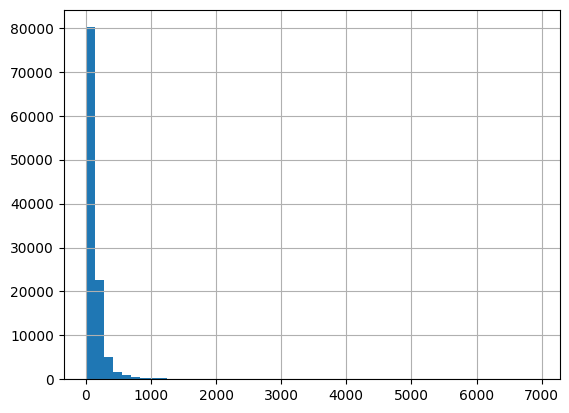

In [24]:
df_data_mart_short['revenue'].hist(bins=50)

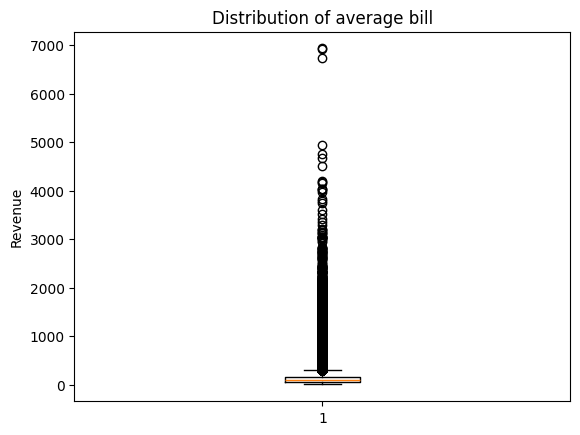

In [25]:
plt.boxplot(df_data_mart_short['revenue'])
plt.title('Distribution of average bill')
plt.ylabel('Revenue')
plt.show()

<Axes: >

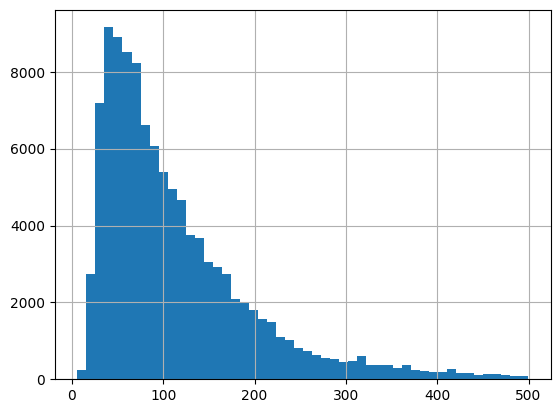

In [26]:
df_data_mart_limited = pd.read_sql(
    """
    SELECT 
        revenue
    FROM data_mart
    WHERE revenue < 500
    """,conn)
df_data_mart_limited['revenue'].hist(bins=50)

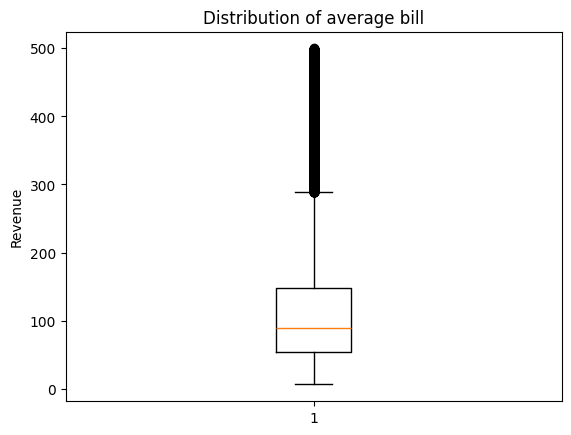

In [27]:
plt.boxplot(df_data_mart_limited['revenue'])
plt.title('Distribution of average bill')
plt.ylabel('Revenue')
plt.show()

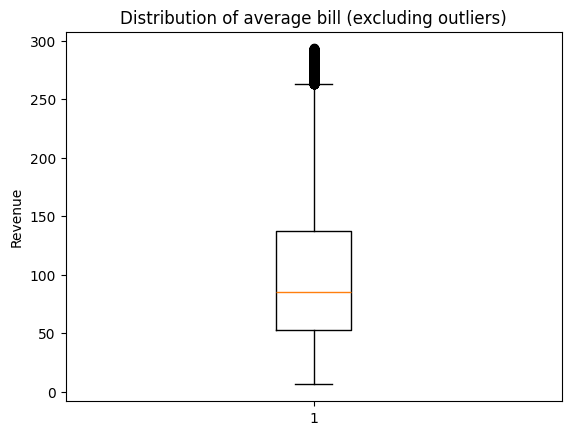

In [28]:
q95 = df_data_mart_limited['revenue'].quantile(0.95)
plt.boxplot(df_data_mart_limited[df_data_mart_limited['revenue'] < q95]['revenue'])
plt.title('Distribution of average bill (excluding outliers)')
plt.ylabel('Revenue')
plt.savefig('../reports/figures/13_Distribution_of_average_bill_excluding_outliers.png')

#### Insights:
- Order values are highly skewed with a long tail
- High-value orders significantly impact revenue metrics

## Analysis of the impact of emissions on company income

In [29]:
df_data_mart_short[df_data_mart_short['revenue'] <= q95]['revenue'].sum() / df_data_mart_short['revenue'].sum()

np.float64(0.6603902828043918)

In [30]:
df_data_mart_short[df_data_mart_short['revenue'] > q95]['revenue'].sum() / df_data_mart_short['revenue'].sum()

np.float64(0.3396097171956082)

In [31]:
df_data_mart_short[df_data_mart_short['revenue'] > q95]['product_category_name'].nunique() / df_data_mart_short['product_category_name'].nunique()

0.8648648648648649

In [32]:
df_data_mart_short[df_data_mart_short['revenue'] > q95]['order_item_id'].describe()

count    9093.000000
mean        1.082591
std         0.429727
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        10.000000
Name: order_item_id, dtype: float64

#### Top 5% of orders generate about 34% of total revenue.
#### High order values are driven by item price rather than basket size (average items per order = 1).
#### This pattern is consistent across categories (coverage 86% of revenue).

In [33]:
df_data_mart_short['price'].median()

np.float64(74.99)

In [34]:
df_data_mart_short[df_data_mart_short['revenue'] > q95]['price'].median()

np.float64(395.65)

#### Insights:
- Top 5% of orders generate about 34% of revenue and are driven by high-priced products (median 396 vs 75)
- This indicates a strong high-value segment spread across most categories

In [35]:
median_of_product_category = df_data_mart_short.groupby('product_category_name')['price'].median()
quantile_of_product_category = df_data_mart_short.groupby('product_category_name')['price'].quantile(0.90)
megrged_df = pd.merge(median_of_product_category,quantile_of_product_category,on='product_category_name')
megrged_df = megrged_df.rename(columns={'price_x':'price_median','price_y':'price_quantile'})
megrged_df['difference_times'] = megrged_df['price_quantile'] / megrged_df['price_median']
megrged_df.sort_values(by='difference_times',ascending=False).head(10)

,price_median,price_quantile,difference_times
product_category_name,,,
portateis_cozinha_e_preparadores_de_alimentos,34.900,979.000,28.051576
telefonia_fixa,60.000,587.190,9.786500
eletroportateis,99.000,849.000,8.575758
instrumentos_musicais,94.835,740.900,7.812516
eletronicos,21.900,135.900,6.205479
consoles_games,59.000,357.100,6.052542
musica,54.890,329.000,5.993806
dvds_blu_ray,19.900,116.900,5.874372
telefonia,29.990,174.963,5.834045


In [36]:
megrged_df['difference_times'].quantile(0.9)

np.float64(5.862273705975696)

#### Premium segment categories (P90 / median > 6):
- portateis cozinha e preparadores de alimentos  
- telefonia fixa
- eletroportateis  
- instrumentos musicais
- eletronicos
- consoles games

In [37]:
conn.close()